<a href="https://colab.research.google.com/github/Lewys-Tech/Hands-on-Machine-Learning/blob/ml-model/Training_a_Binary_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install --upgrade scikit-learn

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

# Load MNIST data
print("Downloading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
print("Download complete!")


Download complete!


In [14]:
# Instead of:
# X, y= mnist["data"], mnist["target"]

# Use the variables obtained from mnist.load_data():
X, y = X_train, y_train
# Or
# X, y = X_test, y_test

# Depending on which data you intend to use.
X.shape

(56000, 784)

In [15]:
y.shape

(56000,)

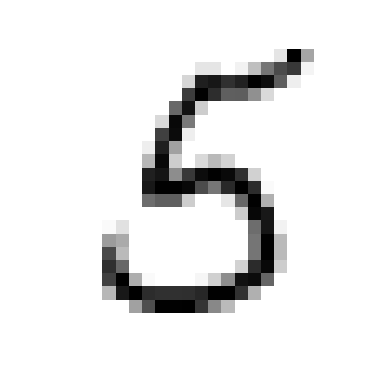

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Access the first row using .iloc
some_digit = X[0]



some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [19]:
y[0]

5

In [20]:
y= y.astype(np.uint8)

In [21]:
X_train, X_test, y_train, y_test= X[:60000], X[60000:], y[:60000], y[60000:]

In [22]:
y_train_5 = (y_train == 5) #True for all 5s, False for all other digits
y_test_5 = (y_test == 5)

In [23]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
#The SGDClassifier relies on randomness during training (hence the name “stochastic”)

SGDClassifier(random_state=42)

In [24]:
import numpy as np
sgd_clf.predict([some_digit])
np.array([True])

array([ True])

In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds = StratifiedKFold(n_splits=3, random_state=None)
for train_index, test_index in skfolds.split(X_train, y_train_5):
 clone_clf = clone(sgd_clf)
 X_train_folds = X_train[train_index]
 y_train_folds = y_train_5[train_index]
 X_test_fold = X_train[test_index]
 y_test_fold = y_train_5[test_index]
 clone_clf.fit(X_train_folds, y_train_folds)
 y_pred = clone_clf.predict(X_test_fold)
 n_correct = sum(y_pred == y_test_fold)
 print(n_correct / len(y_pred))

0.9719290726951304
0.9685541329619114
0.9602485803064396


In [29]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.97192907, 0.96855413, 0.96024858])

In [31]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
  def fit(self, X, y=None):
    return self
    def predict(self, X):
      return np.zeros((len(X), 1), dtype=bool)

    never_5_clf = Never5Classifier()
    cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")
